In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
print(df.duplicated().sum())

0


In [19]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [20]:
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished': 1,
    'semi-furnished': 2,
    'unfurnished': 3
})

In [21]:
df['mainroad']= df['mainroad'].map({
    'yes': 1,
    'no': 0
})

In [22]:
df['airconditioning']= df['airconditioning'].map({
    'yes': 1,
    'no': 0
})


In [23]:
columns = ['guestroom', 'basement', 'hotwaterheating',"prefarea"]

df[columns]= df[columns].replace({
    "yes" : 1,
    "no": 0
})

In [24]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,NaN,0,0,0,NaN,2,1,NaN
1,12250000,8960,4,4,4,NaN,0,0,0,NaN,3,0,NaN
2,12250000,9960,3,2,2,NaN,0,1,0,NaN,2,1,NaN
3,12215000,7500,4,2,2,NaN,0,1,0,NaN,3,1,NaN
4,11410000,7420,4,1,2,NaN,1,1,0,NaN,2,0,NaN


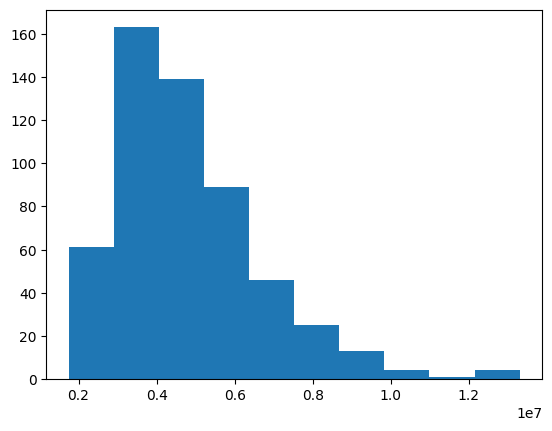

In [25]:
plt.hist(df['price'])
plt.show()

In [26]:
X = df[['area','bedrooms','bathrooms','stories','parking','furnishingstatus','mainroad','guestroom', 'basement', 'hotwaterheating',"prefarea"]]
y = df['price']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:5])

In [29]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1062847.1486609692


In [17]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.604833170367538


C:\Users\patil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: X has 7 features, but LinearRegression is expecting 11 features as input.